In [ ]:
import pandas as pd

In [ ]:
# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/household_power_consumption.txt',
                 sep=';',
                 low_memory=False)

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    object 
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
dtypes: float64(1), object(8)
memory usage: 142.5+ MB


In [ ]:
df.describe()


,Sub_metering_3
count,2.049280e+06
mean,6.458447e+00
std,8.437154e+00
min,0.000000e+00
25%,0.000000e+00
50%,1.000000e+00
75%,1.700000e+01
max,3.100000e+01


Convert Global_active_power;Global_reactive_power;Voltage;Global_intensity;Sub_metering_1;Sub_metering_2 to numeric

In [ ]:
df_numeric = ['Global_active_power','Global_reactive_power','Voltage','Global_intensity','Sub_metering_1','Sub_metering_2','Sub_metering_3']
for num in df_numeric:
    df[num] = pd.to_numeric(df[num], errors='coerce')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 142.5+ MB


Find Missing Values

In [ ]:
missing_counts = df.isna().sum()
print(missing_counts)

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64


Dropping the missing rows since only <5% of data is missing.


In [ ]:
df.dropna(inplace=True)
df.isnull().sum()

,0
Date,0
Time,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,0


In [ ]:
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True, errors='coerce')


df.drop(['Date', 'Time'], axis=1, inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2049280 entries, 0 to 2075258
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Global_active_power    float64       
 1   Global_reactive_power  float64       
 2   Voltage                float64       
 3   Global_intensity       float64       
 4   Sub_metering_1         float64       
 5   Sub_metering_2         float64       
 6   Sub_metering_3         float64       
 7   Datetime               datetime64[ns]
dtypes: datetime64[ns](1), float64(7)
memory usage: 140.7 MB


EDA

<Axes: >

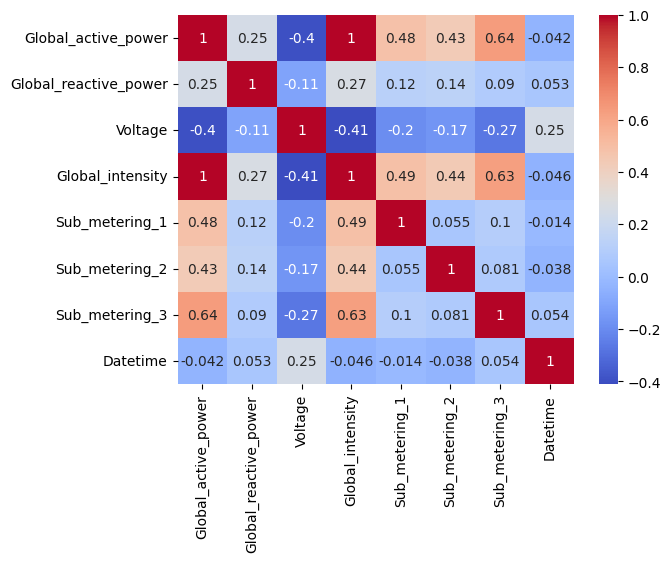

In [ ]:
import seaborn as sns
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

Classification of Usage Patterns
Target: Label data into "high", "medium", "low" usage

Models: SVM, Decision Tree, Logistic Regression

Use case: Understand what conditions lead to spikes

In [ ]:
quantiles = df['Global_active_power'].quantile([0.33, 0.66])
low_th = quantiles[0.33]
high_th = quantiles[0.66]

def categorize_usage(value):
    if value <= low_th:
        return 'Low'
    elif value <= high_th:
        return 'Medium'
    else:
        return 'High'

df['Usage_Class'] = df['Global_active_power'].apply(categorize_usage)


In [ ]:
df['hour'] = df['Datetime'].dt.hour
df['dayofweek'] = df['Datetime'].dt.dayofweek
df['is_weekend'] = df['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

In [ ]:
import numpy as np

# Define thresholds
bins = [0, 2, 4, df['Global_active_power'].max()]  # Adjust if needed
labels = ['Low', 'Medium', 'High']

# Create new column
df['power_class'] = pd.cut(df['Global_active_power'], bins=bins, labels=labels, include_lowest=True)


In [ ]:
print(df['power_class'].value_counts())

power_class
Low       1743278
Medium     258961
High        47041
Name: count, dtype: int64


In [ ]:
features = [
    'hour', 'dayofweek', 'is_weekend',
    'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3',
    'Voltage', 'Global_reactive_power', 'Global_intensity'
]

X = df[features]
y = df['power_class']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[  9331      0     77]
 [     0 347933    723]
 [   154    385  51253]]
              precision    recall  f1-score   support

        High       0.98      0.99      0.99      9408
         Low       1.00      1.00      1.00    348656
      Medium       0.98      0.99      0.99     51792

    accuracy                           1.00    409856
   macro avg       0.99      0.99      0.99    409856
weighted avg       1.00      1.00      1.00    409856



In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_model.fit(X_train, y_train)


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [ ]:
y_pred = lr_model.predict(X_test)

# Then evaluate again
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[  9290      0    118]
 [     0 345027   3629]
 [  1026    250  50516]]
              precision    recall  f1-score   support

        High       0.90      0.99      0.94      9408
         Low       1.00      0.99      0.99    348656
      Medium       0.93      0.98      0.95     51792

    accuracy                           0.99    409856
   macro avg       0.94      0.98      0.96    409856
weighted avg       0.99      0.99      0.99    409856



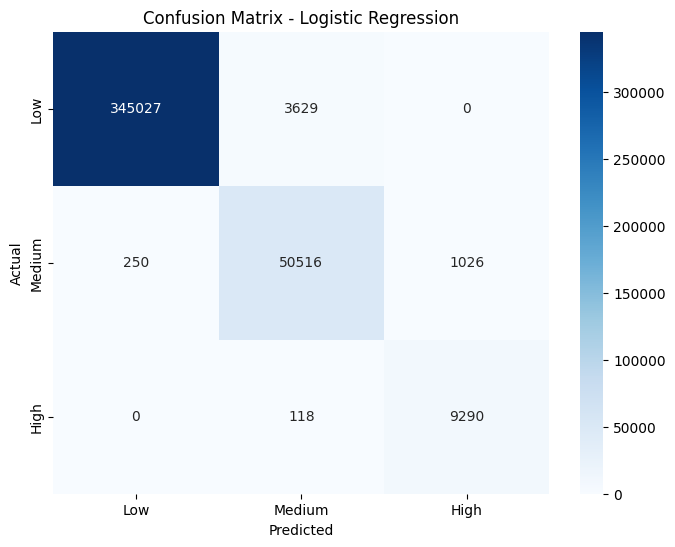

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=['Low', 'Medium', 'High'])

# Plot
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()
